In [1]:
from google.colab import files
uploaded = files.upload()

Saving UAVIDS-2025.csv to UAVIDS-2025.csv


In [2]:
!pip install xgboost pycryptodome scikit-learn pandas numpy matplotlib seaborn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hmac
import hashlib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.utils import to_categorical
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad

import warnings
warnings.filterwarnings('ignore')
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [4]:
df = pd.read_csv('UAVIDS-2025.csv')
print('Forma del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

Forma del dataset: (122171, 23)

Primeras filas:


,FlowID,FlowDuration/s,SrcAddr,SrcPort,DstAddr,DstPort,Protocol,TxPackets,RxPackets,LostPackets,...,RxPacketRate/s,TxByteRate/s,RxByteRate/s,MeanDelay/s,MeanJitter/s,Throughput/Kbps,MeanPacketSize,PacketDropRate,AverageHopCount,label
0,1,175.007,192.168.0.150,9,192.168.0.16,9,UDP,251,215,36,...,1.22853,109.002,93.3679,0.022152,0.024406,0.746943,76,0.143426,0.074419,Sybil Attack
1,2,175.008,192.168.0.150,9,192.168.0.19,9,UDP,251,223,28,...,1.27423,109.001,96.8411,0.019637,0.018678,0.774729,76,0.111554,0.053812,Sybil Attack
2,3,175.010,192.168.0.150,9,192.168.0.24,9,UDP,251,224,27,...,1.27993,108.999,97.2744,0.023701,0.023917,0.778195,76,0.107570,0.044643,Sybil Attack
3,4,175.014,192.168.0.150,9,192.168.0.34,9,UDP,251,212,39,...,1.21133,108.997,92.0614,0.034014,0.025408,0.736491,76,0.155378,0.033019,Sybil Attack
4,5,175.017,192.168.0.150,9,192.168.0.39,9,UDP,251,215,36,...,1.22845,108.995,93.3623,0.034396,0.024933,0.746899,76,0.143426,0.009302,Sybil Attack


Distribución de clases:
label
Normal Traffic      26172
Blackhole Attack    26110
Wormhole Attack     26086
Sybil Attack        24077
Flooding Attack     19726
Name: count, dtype: int64

Porcentaje por clase:
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1
Name: proportion, dtype: float64


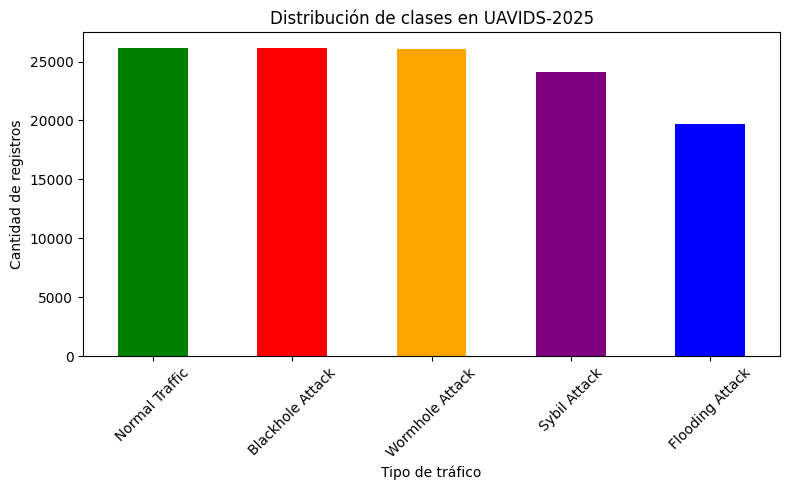

In [5]:
print('Distribución de clases:')
print(df['label'].value_counts())
print('\nPorcentaje por clase:')
print(df['label'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['green','red','orange','purple','blue'])
plt.title('Distribución de clases en UAVIDS-2025')
plt.xlabel('Tipo de tráfico')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150)
plt.show()

In [6]:
print(f'Registros ANTES de limpieza: {df.shape[0]}')
df = df.drop_duplicates()
print(f'Registros DESPUÉS de limpieza: {df.shape[0]}')
print(f'Registros eliminados: {122171 - df.shape[0]}')

X = df.drop(['label', 'SrcAddr', 'DstAddr', 'Protocol'], axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('\nClases codificadas:', dict(zip(le.classes_, le.transform(le.classes_))))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'\nEntrenamiento: {X_train.shape[0]} registros')
print(f'Prueba: {X_test.shape[0]} registros')

Registros ANTES de limpieza: 122171
Registros DESPUÉS de limpieza: 122171
Registros eliminados: 0

Clases codificadas: {'Blackhole Attack': np.int64(0), 'Flooding Attack': np.int64(1), 'Normal Traffic': np.int64(2), 'Sybil Attack': np.int64(3), 'Wormhole Attack': np.int64(4)}

Entrenamiento: 97736 registros
Prueba: 24435 registros


In [7]:
def cifrar_aes(datos: bytes, clave: bytes) -> bytes:
    cipher = AES.new(clave, AES.MODE_CBC)
    return cipher.iv + cipher.encrypt(pad(datos, AES.block_size))

def descifrar_aes(datos_cifrados: bytes, clave: bytes) -> bytes:
    iv = datos_cifrados[:16]
    cipher = AES.new(clave, AES.MODE_CBC, iv)
    return unpad(cipher.decrypt(datos_cifrados[16:]), AES.block_size)

def generar_hmac(mensaje: bytes, clave_secreta: bytes) -> str:
    return hmac.new(clave_secreta, mensaje, hashlib.sha256).hexdigest()

def verificar_hmac(mensaje: bytes, clave_secreta: bytes, hmac_recibido: str) -> bool:
    return hmac.compare_digest(generar_hmac(mensaje, clave_secreta), hmac_recibido)

clave_aes  = os.urandom(16)
clave_hmac = os.urandom(32)
mensaje_prueba = b'Paquete de datos UAV: coordenadas GPS [lat=-12.0, lon=-77.0]'

codigo_hmac        = generar_hmac(mensaje_prueba, clave_hmac)
autenticado        = verificar_hmac(mensaje_prueba, clave_hmac, codigo_hmac)
mensaje_cifrado    = cifrar_aes(mensaje_prueba, clave_aes)
mensaje_descifrado = descifrar_aes(mensaje_cifrado, clave_aes)

print('=== PRUEBA DEL SISTEMA DE SEGURIDAD ===')
print(f'Mensaje original:      {mensaje_prueba.decode()}')
print(f'Autenticación HMAC:    {"VÁLIDA" if autenticado else "INVÁLIDA"}')
print(f'Mensaje cifrado:       {mensaje_cifrado[:20].hex()}... (AES-128)')
print(f'Mensaje descifrado:    {mensaje_descifrado.decode()}')
print(f'Integridad verificada: {mensaje_prueba == mensaje_descifrado}')

=== PRUEBA DEL SISTEMA DE SEGURIDAD ===
Mensaje original:      Paquete de datos UAV: coordenadas GPS [lat=-12.0, lon=-77.0]
Autenticación HMAC:    VÁLIDA
Mensaje cifrado:       1b3d7ea2eaf58391ba312c7ea3ab548d1ed71b5e... (AES-128)
Mensaje descifrado:    Paquete de datos UAV: coordenadas GPS [lat=-12.0, lon=-77.0]
Integridad verificada: True


In [8]:
resultados = {}

# Reshape para modelos de red neuronal
num_clases  = len(np.unique(y_encoded))
y_train_cat = to_categorical(y_train, num_clases)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Random Forest
print('Entrenando Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
resultados['Random Forest'] = rf.predict(X_test)
print('Random Forest completado')

# XGBoost
print('Entrenando XGBoost...')
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
resultados['XGBoost'] = xgb.predict(X_test)
print('XGBoost completado')

# SVM
print('Entrenando SVM...')
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
resultados['SVM'] = svm.predict(X_test)
print('SVM completado')

# CNN
print('Entrenando CNN...')
from tensorflow.keras.layers import Flatten # Import Flatten layer
cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu',
           input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(), # Add Flatten layer here
    Dense(32, activation='relu'),
    Dense(num_clases, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])
cnn.fit(X_train_cnn, y_train_cat,
        epochs=20, batch_size=64,
        validation_split=0.1, verbose=1)
resultados['CNN'] = np.argmax(cnn.predict(X_test_cnn), axis=1)
print('CNN completado')

# LSTM
print('Entrenando LSTM...')
lstm = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train.shape[1], 1)),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_clases, activation='softmax')
])
lstm.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])
lstm.fit(X_train_cnn, y_train_cat,
         epochs=20, batch_size=64,
         validation_split=0.1, verbose=1)
resultados['LSTM'] = np.argmax(lstm.predict(X_test_cnn), axis=1)
print('LSTM completado')

print('\nTodos los modelos entrenados correctamente')

Entrenando Random Forest...
Random Forest completado
Entrenando XGBoost...
XGBoost completado
Entrenando SVM...
SVM completado
Entrenando CNN...
Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8250 - loss: 0.4772 - val_accuracy: 0.9134 - val_loss: 0.2605
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9082 - loss: 0.2580 - val_accuracy: 0.9456 - val_loss: 0.1779
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9293 - loss: 0.1972 - val_accuracy: 0.9620 - val_loss: 0.1297
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9410 - loss: 0.1674 - val_accuracy: 0.9630 - val_loss: 0.1210
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9503 - loss: 0.1450 - val_accuracy: 0.9633 - val_loss: 0.1100
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9545 - loss: 0.1317 - val_accuracy: 0.9661 - val_loss: 0.1034
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9573

In [9]:
tabla_resultados = []

for nombre, y_pred in resultados.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    tabla_resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall':    round(rec  * 100, 2),
        'F1-Score':  round(f1   * 100, 2)
    })

df_resultados = pd.DataFrame(tabla_resultados)
print('=== TABLA COMPARATIVA DE RESULTADOS ===')
print(df_resultados.to_string(index=False))
df_resultados.to_csv('resultados_modelos.csv', index=False)


=== TABLA COMPARATIVA DE RESULTADOS ===
       Modelo  Accuracy  Precision  Recall  F1-Score
Random Forest     99.99      99.99   99.99     99.99
      XGBoost     99.98      99.98   99.98     99.98
          SVM     97.04      97.10   97.04     97.04
          CNN     98.71      98.71   98.71     98.71
         LSTM     99.22      99.22   99.22     99.22


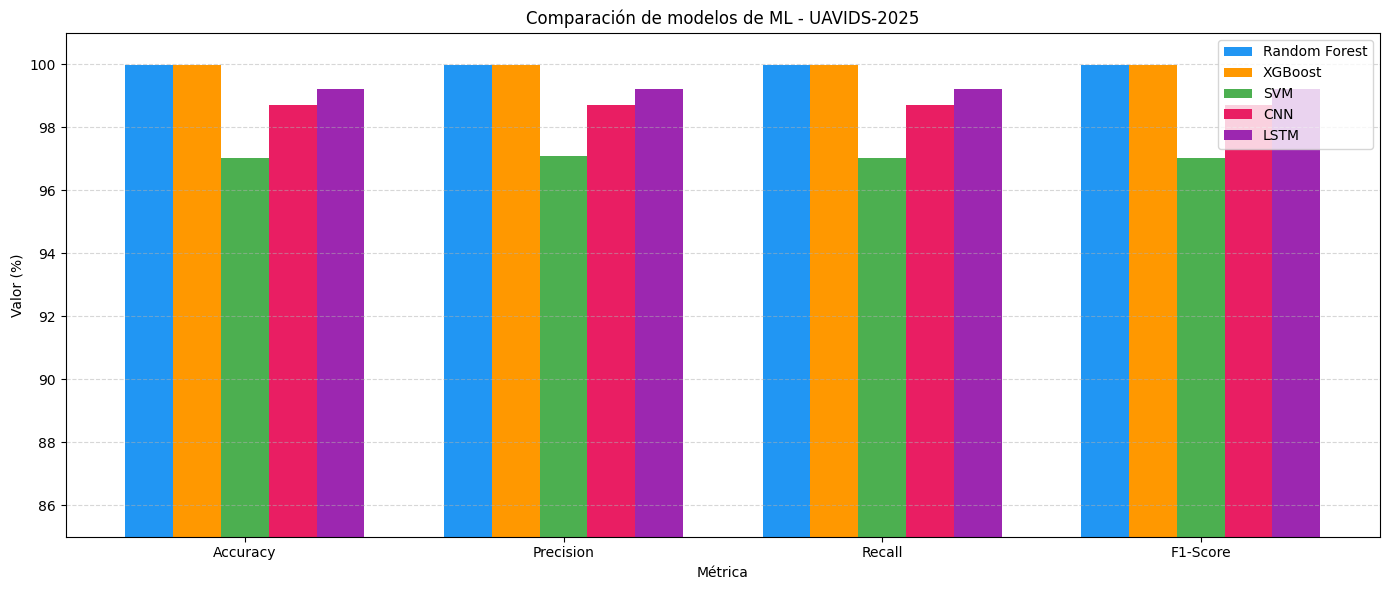

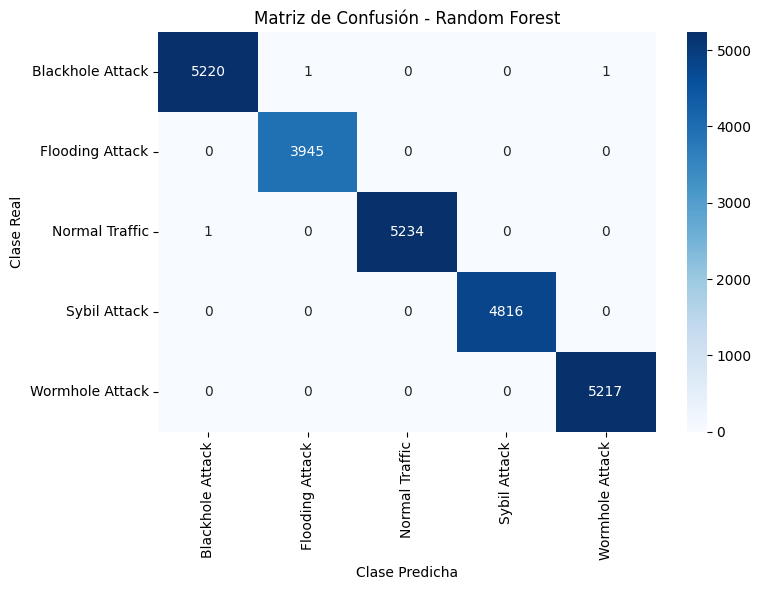


Mejor modelo: Random Forest
F1-Score: 99.99%


In [10]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x      = np.arange(len(metricas))
ancho  = 0.15
colores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, fila) in enumerate(df_resultados.iterrows()):
    valores = [fila[m] for m in metricas]
    ax.bar(x + i * ancho, valores, ancho, label=fila['Modelo'], color=colores[i])

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor (%)')
ax.set_title('Comparación de modelos de ML - UAVIDS-2025')
ax.set_xticks(x + ancho * 2)
ax.set_xticklabels(metricas)
ax.set_ylim(85, 101)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150)
plt.show()

mejor_idx    = df_resultados['F1-Score'].idxmax()
mejor_nombre = df_resultados.loc[mejor_idx, 'Modelo']
mejor_pred   = resultados[mejor_nombre]

cm = confusion_matrix(y_test, mejor_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión - {mejor_nombre}')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()

print(f'\nMejor modelo: {mejor_nombre}')
print(f'F1-Score: {df_resultados.loc[mejor_idx, "F1-Score"]}%')

In [11]:
print(f'=== REPORTE DETALLADO - {mejor_nombre} ===')
print(classification_report(y_test, mejor_pred, target_names=le.classes_))

=== REPORTE DETALLADO - Random Forest ===
                  precision    recall  f1-score   support

Blackhole Attack       1.00      1.00      1.00      5222
 Flooding Attack       1.00      1.00      1.00      3945
  Normal Traffic       1.00      1.00      1.00      5235
    Sybil Attack       1.00      1.00      1.00      4816
 Wormhole Attack       1.00      1.00      1.00      5217

        accuracy                           1.00     24435
       macro avg       1.00      1.00      1.00     24435
    weighted avg       1.00      1.00      1.00     24435

